## Classification of SVHN using Transfer Learning from pre-trained MNIST CNN

### The Street View House Numbers (SVHN) Dataset

SVHN is a real-world image dataset for developing machine learning and object recognition algorithms with minimal requirement on data preprocessing and formatting. It can be seen as similar in flavor to MNIST (e.g., the images are of small cropped digits), but incorporates an order of magnitude more labeled data (over 600,000 digit images) and comes from a significantly harder, real world problem (recognizing digits and numbers in natural scene images). SVHN is obtained from house numbers in Google Street View images.

- 10 classes, 1 for each digit. Digit '1' has label 1, '9' has label 9 and '0' has label 0.
- 73257 digits for training, 26032 digits for testing, and 531131 additional, somewhat less difficult samples, to use as extra training data
- Comes in two formats:
  1. Original images with character level bounding boxes.
  2. MNIST-like 32-by-32 images centered around a single character (many of the images do contain some distractors at the sides).

- The dataset that we will be using in this notebook contains 42000 training samples and 18000 testing samples

Dataset link : https://www.kaggle.com/sasha18/street-view-house-nos-h5-file

# Mounting the Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/My Drive/PES CV Classes/S3_TransferLearning"

In [ ]:
import tensorflow as tf

#The SVHN dataset is provided in the form of h5. We can extract the data as train and test
                                                               

In [ ]:

import h5py

data=h5py.File('SVHN_single_grey1.h5','r')

X_train=data['X_train'][:]
y_train=data['y_train'][:]

X_test=data['X_test'][:]
y_test=data['y_test'][:]

data.close()

# Scaling the data

In [ ]:
x_train=X_train/255.
x_test=X_test/255.

In [ ]:
x_train.shape

(42000, 32, 32)

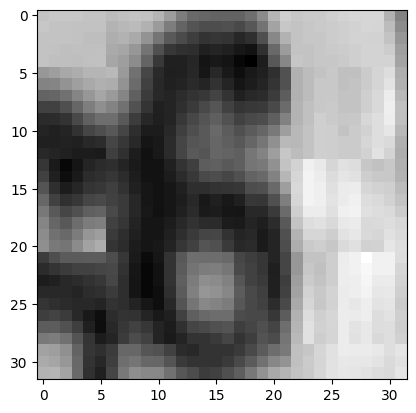

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[20,:,:],cmap='gray')

In [ ]:
y_train[20]

np.uint8(6)

# Resize the images as 28x28
#(MNIST dataset size is 28x28, as we are using the MNIST model weight,
# we need to resize these images as 28x28 )

In [ ]:
import cv2
import numpy as np
X_train_resize=np.zeros((42000,28,28))

for i in range(42000):
    X_train_resize[i,:,:]=cv2.resize(x_train[i],dsize=(28,28))

X_test_resize=np.zeros((18000,28,28))
for i in range(18000):
    X_test_resize[i,:,:]=cv2.resize(x_test[i],dsize=(28,28))

In [ ]:
X_train_resize.shape

(42000, 28, 28)

# Reshape the train and test datasets to make them 4-D

In [ ]:
xtrain1=X_train_resize.reshape(42000,28,28,1) # u can also use np.expand_dim
xtest1=X_test_resize.reshape(18000,28,28,1)

# Encoding the target variable

In [ ]:
from tensorflow.keras.utils import to_categorical
ytrain=to_categorical(y_train,num_classes=10)
ytest=to_categorical(y_test,num_classes=10)
ytrain[0]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

# Import the libraries required for CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

# What should be the architecture?

In [ ]:
classifier1=Sequential()

classifier1.add(Conv2D(16,(3,3),input_shape=(28,28,1),activation ='relu'))
classifier1.add(MaxPooling2D(pool_size=(2,2)))

classifier1.add(Conv2D(32,(3,3),activation ='relu'))
classifier1.add(MaxPooling2D(pool_size=(2,2)))

classifier1.add(Flatten())

classifier1.add(Dense(units=64,activation='relu'))
classifier1.add(Dense(units=10,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Apply the MNIST data model weight on the above CNN architecture

In [ ]:
classifier1.load_weights('mnist_cnn_model.h5')

# Compilation statergy

In [ ]:
classifier1.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

# Evaluating the model on the SVHN dataset

In [ ]:
classifier1.evaluate(xtest1,ytest)

563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1728 - loss: 2.5695


[2.5695419311523438, 0.17277777194976807]

# Accessing the layers

In [ ]:
classifier1.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>]

# Accessing the layer name

In [ ]:
for layer in classifier1.layers:
    print(layer.name)

conv2d
max_pooling2d
conv2d_1
max_pooling2d_1
flatten
dense
dense_1


# Trainability nature of each layer.
#by default all layer weights are trainable

In [ ]:
for layer in classifier1.layers:
    print(layer.trainable)

True
True
True
True
True
True
True


# freeze the convolution layer and train only the dense layer

In [ ]:
for layer in classifier1.layers:
    if ('dense' not in layer.name):
        layer.trainable=False
    if('dense' in layer.name):
        layer.trainable=True

# False indicating that these layers can't be trainable (i.e the weights are freezed)

In [ ]:
for layer in classifier1.layers:
    print(layer.name,layer.trainable)

conv2d False
max_pooling2d False
conv2d_1 False
max_pooling2d_1 False
flatten False
dense True
dense_1 True


In [ ]:
classifier1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 51,914 (202.79 KB)

 Non-trainable params: 4,800 (18.75 KB)

# Training the model. In this step only the weights of dense layers will be updated
# convolution layer weights remain same(same as MNIST model weights)

In [ ]:
classifier1.fit(xtrain1,ytrain,batch_size=32,epochs=10,validation_data=(xtest1,ytest))

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6655 - loss: 1.1458 - val_accuracy: 0.7521 - val_loss: 0.8766
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7750 - loss: 0.7945 - val_accuracy: 0.7848 - val_loss: 0.7628
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8000 - loss: 0.6977 - val_accuracy: 0.8028 - val_loss: 0.7008
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8156 - loss: 0.6413 - val_accuracy: 0.7926 - val_loss: 0.7114
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8258 - loss: 0.6031 - val_accuracy: 0.8216 - val_loss: 0.6450
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8343 - loss: 0.5710 - val_accuracy: 0.8162 - val_loss: 0.6388
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8399 - loss: 0.5457 - val_accuracy: 0.8178 - val_loss: 0.6387
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8440 - loss: 0.5250 - 

# The approach is along with tuning dense layer weights, we can also retrain few last convolution layers


In [ ]:
for layer in classifier1.layers:
    print(layer.name,layer.trainable)
classifier1.layers[2].trainable=True
classifier1.layers[3].trainable=True
classifier1.layers[4].trainable=True
print("After unfreezing last convolution layer")
for layer in classifier1.layers:
    print(layer.name,layer.trainable)

conv2d False
max_pooling2d False
conv2d_1 False
max_pooling2d_1 False
flatten False
dense True
dense_1 True
After unfreezing last convolution layer
conv2d False
max_pooling2d False
conv2d_1 True
max_pooling2d_1 True
flatten True
dense True
dense_1 True


# Train the model. In this step along with all the dense layers, last convolution layer weights also will be updated

In [ ]:
classifier1.fit(xtrain1,ytrain,batch_size=32,epochs=10,validation_data=(xtest1,ytest))

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8579 - loss: 0.4736 - val_accuracy: 0.8333 - val_loss: 0.5950
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8621 - loss: 0.4579 - val_accuracy: 0.8231 - val_loss: 0.6093
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8665 - loss: 0.4458 - val_accuracy: 0.8322 - val_loss: 0.5930
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8699 - loss: 0.4332 - val_accuracy: 0.8356 - val_loss: 0.5905
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8715 - loss: 0.4230 - val_accuracy: 0.8292 - val_loss: 0.6027
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8733 - loss: 0.4135 - val_accuracy: 0.8270 - val_loss: 0.6090
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8771 - loss: 0.4052 - val_accuracy: 0.8343 - val_loss: 0.5909
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8798 - loss: 0.3945 - 

# Reduce overfitting - Include dropout layer

In [ ]:
classifier1=Sequential()

classifier1.add(Conv2D(16,(3,3),input_shape=(28,28,1),activation ='relu'))
classifier1.add(MaxPooling2D(pool_size=(2,2)))

classifier1.add(Conv2D(32,(3,3),activation ='relu'))
classifier1.add(MaxPooling2D(pool_size=(2,2)))
classifier1.add(Dropout(0.2))

classifier1.add(Flatten())

classifier1.add(Dense(units=64,activation='relu'))
classifier1.add(Dropout(0.2))
classifier1.add(Dense(units=10,activation='softmax'))

In [ ]:
for layer in classifier1.layers:
    print(layer.name,layer.trainable)

conv2d_2 True
max_pooling2d_2 True
conv2d_3 True
max_pooling2d_3 True
dropout True
flatten_1 True
dense_2 True
dropout_1 True
dense_3 True


In [ ]:
classifier1.load_weights('mnist_cnn_model.h5')

In [ ]:
for layer in classifier1.layers:
    if ('dense' not in layer.name):
        layer.trainable=False
    if('dense' in layer.name):
        layer.trainable=True

In [ ]:
classifier1.layers[2].trainable=True

In [ ]:
classifier1.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
classifier1.fit(xtrain1,ytrain,batch_size=32,epochs=5,validation_data=(xtest1,ytest))

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6817 - loss: 1.0259 - val_accuracy: 0.8176 - val_loss: 0.6327
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.7864 - loss: 0.7053 - val_accuracy: 0.8502 - val_loss: 0.5370
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8078 - loss: 0.6288 - val_accuracy: 0.8601 - val_loss: 0.5032
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8236 - loss: 0.5820 - val_accuracy: 0.8657 - val_loss: 0.4770
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8292 - loss: 0.5533 - val_accuracy: 0.8738 - val_loss: 0.4369
